# Refined exact flattened-state wall-charge pump

This notebook replaces the retired H3 entanglement-flow geometry with a direct real-space Laughlin-pump diagnostic. It starts from the exact half-filled ground state of the canonical flattened Hamiltonian and compares:

- **Instantaneous control:** reselect the lowest \(N_xN_y\) states at every twist. It must close to zero transferred wall charge.
- **Continued branch:** retain the initial occupations while overlap-continuing the eigenvectors through the flux cycle. A unit Chern pump should transfer one charge between the two walls.

The production mesh contains a 257-point global loop and 257-point refinements over the first and last \(0.08\pi\) of the cycle. The older 129-point grid is retained as a nested convergence control. No entanglement spectra are calculated.

## CPU controls — run before numerical imports

In [1]:
import os
import multiprocessing as _mp

CPU_START = None
CPU_STOP = None
CPU_COUNT = 8

_allowed = sorted(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity") else list(range(_mp.cpu_count()))
if CPU_START is not None or CPU_STOP is not None:
    if CPU_START is None or CPU_STOP is None or int(CPU_STOP) < int(CPU_START):
        raise ValueError("Set a valid inclusive CPU_START/CPU_STOP pair.")
    _resolved = [c for c in range(int(CPU_START), int(CPU_STOP) + 1) if c in _allowed]
    if not _resolved:
        raise RuntimeError("Requested CPUs do not intersect the allowed affinity mask.")
else:
    _resolved = _allowed[:max(1, min(int(CPU_COUNT), len(_allowed)))]
if hasattr(os, "sched_setaffinity"):
    os.sched_setaffinity(0, _resolved)
for _name in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
              "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_name] = str(len(_resolved))

SMOKE = os.environ.get("FLAT_PUMP_SMOKE", "0") == "1"
OUTPUT_ROOT_OVERRIDE = os.environ.get("FLAT_PUMP_OUTPUT_ROOT", "")
print({"smoke": SMOKE, "cpus": _resolved, "threads": len(_resolved)})

{'smoke': False, 'cpus': [0, 1, 2, 3, 4, 5, 6, 7], 'threads': 8}


## Imports and configuration

In [2]:
from pathlib import Path
import contextlib
import datetime as dt
import hashlib
import io
import json
import time

_here = Path.cwd().resolve()
REPO_ROOT = next((p for p in [_here, *_here.parents]
                  if (p / "src" / "fgtn" / "classA_U1FGTN.py").exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Repository root not found.")
import sys
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm.auto import tqdm
from fgtn.classA_U1FGTN import classA_U1FGTN

SOURCE = REPO_ROOT / "src" / "fgtn" / "classA_U1FGTN.py"
SOURCE_HASH = hashlib.sha256(SOURCE.read_bytes()).hexdigest()
RUN_ID = dt.datetime.now().strftime("run_%Y%m%d_%H%M%S")
DEFAULT_BASE = (REPO_ROOT / "notebooks" / "flattened_hamiltonian_analysis" / "outputs"
                / "exact_wall_charge_pump_refined_v1")
OUTPUT_BASE = Path(OUTPUT_ROOT_OVERRIDE).resolve() if OUTPUT_ROOT_OVERRIDE else DEFAULT_BASE
OUTPUT_DIR = OUTPUT_BASE / RUN_ID
FIGURE_DIR = OUTPUT_DIR / "figures"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["CMU Sans Serif", "DejaVu Sans"],
    "mathtext.fontset": "cm", "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "figure.dpi": 120, "savefig.dpi": 300,
})

if SMOKE:
    NX, NY, DW_INTERVAL = 8, 12, (2, 6)
    GLOBAL_FINE_N, ENDPOINT_N = 17, 17
    GLOBAL_COARSE_N = 9
else:
    NX, NY, DW_INTERVAL = 20, 40, (5, 15)
    GLOBAL_FINE_N, ENDPOINT_N = 257, 257
    GLOBAL_COARSE_N = 129

NSHELL = 1
ALPHA_TOP, ALPHA_TRIV = 1.0, 30.0
TRIAL_ORBITAL = "X"
DW_TRUNCATIONS = (False, True)
DIRECTIONS = (+1, -1)
RANK = NX * NY
ORBITALS_PER_Y = 2 * NX
PHI_OFFSET = 1e-7
ENDPOINT_SPAN = 0.08 * np.pi
DEGENERACY_TOL = 1e-9
WALL_WINDOW = 2
SAVE_OUTPUTS = True

CONFIG = {
    "Nx": NX, "Ny": NY, "rank": RANK, "dw_interval": DW_INTERVAL,
    "nshell": NSHELL, "alpha_top": ALPHA_TOP, "alpha_triv": ALPHA_TRIV,
    "trial_orbital": TRIAL_ORBITAL, "dw_truncations": DW_TRUNCATIONS,
    "directions": DIRECTIONS, "global_coarse_n": GLOBAL_COARSE_N,
    "global_fine_n": GLOBAL_FINE_N, "endpoint_n_each": ENDPOINT_N,
    "endpoint_span_over_pi": ENDPOINT_SPAN / np.pi,
    "phi_offset": PHI_OFFSET, "source_sha256": SOURCE_HASH, "smoke": SMOKE,
}
print(json.dumps(CONFIG, indent=2, default=list))
print("Output:", OUTPUT_DIR)

{
  "Nx": 20,
  "Ny": 40,
  "rank": 800,
  "dw_interval": [
    5,
    15
  ],
  "nshell": 1,
  "alpha_top": 1.0,
  "alpha_triv": 30.0,
  "trial_orbital": "X",
  "dw_truncations": [
    false,
    true
  ],
  "directions": [
    1,
    -1
  ],
  "global_coarse_n": 129,
  "global_fine_n": 257,
  "endpoint_n_each": 257,
  "endpoint_span_over_pi": 0.08,
  "phi_offset": 1e-07,
  "source_sha256": "2c8e86664d8d16da13b09670cc1cb78d2b0e14ff676b128dff169cba1272f2c5",
  "smoke": false
}
Output: /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis/outputs/exact_wall_charge_pump_refined_v1/run_20260901_002219


## Hamiltonian, twist grids, continuation, and real-space charge

The basis is \(i=\mu+2x+2N_xy\). The two complementary basins assign each site to its nearer wall; midpoint ties receive half weight from each wall. Consequently \(W_L+W_R=I\), so any nonzero \(\Delta Q_L+\Delta Q_R\) is a numerical error rather than an arbitrary window effect.

In [3]:
def frame_projector(frame):
    v = np.asarray(frame, dtype=np.complex128).reshape(2 * NX * NY, NX * NY, order="F")
    return v @ v.conj().T

def build_hflat(phi, truncation):
    with contextlib.redirect_stdout(io.StringIO()):
        model = classA_U1FGTN(
            Nx=NX, Ny=NY, DW=True, nshell=NSHELL, filling_frac=0.5,
            alpha_1=ALPHA_TOP, alpha_2=ALPHA_TRIV,
            trial_orbitals=TRIAL_ORBITAL, dw_truncation=truncation,
            twist_y=float(phi), dw_interval=DW_INTERVAL,
        )
        model.construct_OW_projectors(
            nshell=NSHELL, DW=True, trial_orbitals=TRIAL_ORBITAL,
            dw_truncation=truncation, twist_y=float(phi),
        )
    h = (frame_projector(model.WF_Ap) + frame_projector(model.WF_Bp)
         - frame_projector(model.WF_Am) - frame_projector(model.WF_Bm))
    return np.asarray(0.5 * (h + h.conj().T), dtype=np.complex128)

def y_blocks(matrix):
    shaped = matrix.reshape(NY, ORBITALS_PER_Y, NY, ORBITALS_PER_Y)
    transformed = np.fft.ifft(np.fft.fft(shaped, axis=0), axis=2)
    blocks = np.stack([transformed[k, :, k, :] for k in range(NY)])
    off = transformed.copy()
    for k in range(NY):
        off[k, :, k, :] = 0
    return blocks, float(np.max(np.abs(off)))

def reconstruct_from_blocks(blocks):
    transformed = np.zeros((NY, ORBITALS_PER_Y, NY, ORBITALS_PER_Y), dtype=np.complex128)
    for k in range(NY):
        transformed[k, :, k, :] = blocks[k]
    shaped = np.fft.ifft(np.fft.fft(transformed, axis=2), axis=0)
    return shaped.reshape(2 * NX * NY, 2 * NX * NY)

def diagonalize_blocks(blocks):
    evals, vecs = [], []
    for block in blocks:
        e, v = np.linalg.eigh(block)
        evals.append(e)
        vecs.append(v)
    return np.asarray(evals), np.asarray(vecs)

def lowest_occupations(evals):
    occupied = np.zeros_like(evals, dtype=bool)
    order = np.argsort(evals, axis=None)[:RANK]
    occupied[np.unravel_index(order, evals.shape)] = True
    return occupied

def projector_from_occupations(vecs, occupied):
    blocks = np.empty((NY, ORBITALS_PER_Y, ORBITALS_PER_Y), dtype=np.complex128)
    for k in range(NY):
        v = vecs[k][:, occupied[k]]
        blocks[k] = v @ v.conj().T
    return reconstruct_from_blocks(blocks)

def continue_eigenbasis(previous, evals, vecs):
    tracked_evals = np.empty_like(evals)
    tracked_vecs = np.empty_like(vecs)
    assigned_min = 1.0
    principal_min = 1.0
    for k in range(NY):
        overlap = np.abs(previous[k].conj().T @ vecs[k]) ** 2
        rows, cols = linear_sum_assignment(-overlap)
        permutation = cols[np.argsort(rows)]
        e = evals[k, permutation]
        v = vecs[k][:, permutation]
        assigned_min = min(assigned_min, float(np.sqrt(overlap[np.arange(len(e)), permutation]).min()))
        unused = set(range(ORBITALS_PER_Y))
        while unused:
            seed = min(unused)
            cluster = sorted(j for j in unused if abs(e[j] - e[seed]) < DEGENERACY_TOL)
            unused -= set(cluster)
            idx = np.asarray(cluster)
            ov = previous[k][:, idx].conj().T @ v[:, idx]
            u, singular, vh = np.linalg.svd(ov, full_matrices=False)
            v[:, idx] = v[:, idx] @ (vh.conj().T @ u.conj().T)
            principal_min = min(principal_min, float(singular.min()))
        tracked_evals[k] = e
        tracked_vecs[k] = v
    return tracked_evals, tracked_vecs, assigned_min, principal_min

def circular_distance(values, center, period):
    values = np.asarray(values)
    return np.abs((values - center + period / 2) % period - period / 2)

_full_x = np.tile(np.repeat(np.arange(NX), 2), NY)
_dleft = circular_distance(_full_x, DW_INTERVAL[0], NX)
_dright = circular_distance(_full_x, DW_INTERVAL[1], NX)
_basin_left = (_dleft < _dright).astype(float) + 0.5 * (_dleft == _dright)
BASIN_WEIGHTS = np.stack([_basin_left, 1.0 - _basin_left])
NARROW_MASKS = np.stack([
    circular_distance(_full_x, wall, NX) <= WALL_WINDOW for wall in DW_INTERVAL
])

def charge_observables(projector):
    diagonal = np.real(np.diag(projector))
    basin = BASIN_WEIGHTS @ diagonal
    narrow = NARROW_MASKS @ diagonal
    density_x = diagonal.reshape(NY, NX, 2).sum(axis=(0, 2))
    return basin, narrow, density_x

def grids_for_direction(direction):
    direction = int(direction)
    coarse = PHI_OFFSET + direction * np.linspace(0, 2 * np.pi, GLOBAL_COARSE_N)
    fine = PHI_OFFSET + direction * np.linspace(0, 2 * np.pi, GLOBAL_FINE_N)
    start = PHI_OFFSET + direction * np.linspace(0, ENDPOINT_SPAN, ENDPOINT_N)
    end = PHI_OFFSET + direction * np.linspace(2 * np.pi - ENDPOINT_SPAN, 2 * np.pi, ENDPOINT_N)
    refined = np.unique(np.round(np.concatenate([fine, start, end]), 15))
    refined = np.sort(refined)
    if direction < 0:
        refined = refined[::-1]
    return {"global_129" if not SMOKE else "global_coarse": coarse,
            "global_257" if not SMOKE else "global_fine": fine,
            "endpoint_refined": refined}

def save_figure(fig, name):
    if SAVE_OUTPUTS:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_DIR / f"{name}.png", bbox_inches="tight")
        fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")

## Parallel nested-grid continuation

In [4]:
class GridTracker:
    def __init__(self, name):
        self.name = name
        self.previous = None
        self.fixed_occupied = None
        self.initial = {}
        self.records = []
        self.final_density = {}

    def update(self, phi, evals, vecs):
        instantaneous_occupied = lowest_occupations(evals)
        p_instantaneous = projector_from_occupations(vecs, instantaneous_occupied)

        if self.previous is None:
            continued_evals, continued_vecs = evals.copy(), vecs.copy()
            self.fixed_occupied = instantaneous_occupied.copy()
            assigned_min = principal_min = 1.0
        else:
            continued_evals, continued_vecs, assigned_min, principal_min = continue_eigenbasis(
                self.previous, evals, vecs
            )
        p_continued = projector_from_occupations(continued_vecs, self.fixed_occupied)
        self.previous = continued_vecs.copy()

        row = {"phi": float(phi), "assigned_min": assigned_min, "principal_min": principal_min}
        for family, projector in (("instantaneous", p_instantaneous), ("continued", p_continued)):
            basin, narrow, density_x = charge_observables(projector)
            if family not in self.initial:
                self.initial[family] = {"basin": basin.copy(), "narrow": narrow.copy(),
                                        "density_x": density_x.copy()}
            delta_basin = basin - self.initial[family]["basin"]
            delta_narrow = narrow - self.initial[family]["narrow"]
            row.update({
                f"delta_Q_left_basin_{family}": float(delta_basin[0]),
                f"delta_Q_right_basin_{family}": float(delta_basin[1]),
                f"q_pump_{family}": float(0.5 * (delta_basin[1] - delta_basin[0])),
                f"charge_residual_{family}": float(delta_basin.sum()),
                f"delta_Q_left_narrow_{family}": float(delta_narrow[0]),
                f"delta_Q_right_narrow_{family}": float(delta_narrow[1]),
            })
            self.final_density[family] = density_x - self.initial[family]["density_x"]
        self.records.append(row)

def run_case(truncation, direction):
    grids = grids_for_direction(direction)
    trackers = {name: GridTracker(name) for name in grids}
    membership = {}
    for name, values in grids.items():
        for value in values:
            membership.setdefault(round(float(value), 14), []).append(name)
    master = np.array(sorted(membership.keys()), dtype=float)
    if direction < 0:
        master = master[::-1]

    validation = {"hermiticity_max": 0.0, "block_offdiag_max": 0.0}
    first_h = last_h = None
    for phi in tqdm(master, desc=f"trunc={truncation}, dir={direction:+d}"):
        h = build_hflat(phi, truncation)
        if first_h is None:
            first_h = h.copy()
        last_h = h
        validation["hermiticity_max"] = max(
            validation["hermiticity_max"], float(np.max(np.abs(h - h.conj().T)))
        )
        blocks, off = y_blocks(h)
        validation["block_offdiag_max"] = max(validation["block_offdiag_max"], off)
        evals, vecs = diagonalize_blocks(blocks)
        for name in membership[round(float(phi), 14)]:
            trackers[name].update(phi, evals, vecs)

    y = np.repeat(np.arange(NY), ORBITALS_PER_Y)
    phase = np.exp(1j * direction * 2 * np.pi * y / NY)
    gauged_first = phase[:, None] * first_h * phase.conj()[None, :]
    validation["h_2pi_closure"] = float(np.max(np.abs(last_h - gauged_first)))
    return {"truncation": truncation, "direction": direction,
            "trackers": trackers, "validation": validation}

started = time.perf_counter()
RESULTS = {(trunc, direction): run_case(trunc, direction)
           for trunc in DW_TRUNCATIONS for direction in DIRECTIONS}
RUNTIME_SECONDS = time.perf_counter() - started
print(f"Runtime: {RUNTIME_SECONDS / 60:.2f} min")
print(pd.DataFrame([
    {"truncation": k[0], "direction": k[1], **case["validation"]}
    for k, case in RESULTS.items()
]).to_string(index=False))

trunc=False, dir=+1:   0%|          | 0/756 [00:00<?, ?it/s]

trunc=False, dir=-1:   0%|          | 0/755 [00:00<?, ?it/s]

trunc=True, dir=+1:   0%|          | 0/756 [00:00<?, ?it/s]

trunc=True, dir=-1:   0%|          | 0/755 [00:00<?, ?it/s]

Runtime: 42.89 min
 truncation  direction  hermiticity_max  block_offdiag_max  h_2pi_closure
      False          1              0.0       9.700507e-16   3.608519e-15
      False         -1              0.0       1.006709e-15   5.957088e-15
       True          1              0.0       9.726665e-16   3.598940e-15
       True         -1              0.0       9.994753e-16   5.956240e-15


## Assemble endpoint and time-series tables

In [5]:
series_rows = []
summary_rows = []
density_rows = []
for (truncation, direction), case in RESULTS.items():
    for grid_name, tracker in case["trackers"].items():
        frame = pd.DataFrame(tracker.records)
        frame["dw_truncation"] = truncation
        frame["direction"] = direction
        frame["grid"] = grid_name
        frame["s"] = np.abs(frame["phi"] - PHI_OFFSET) / (2 * np.pi)
        series_rows.append(frame)
        last = frame.iloc[-1]
        for family in ("instantaneous", "continued"):
            summary_rows.append({
                "dw_truncation": truncation, "direction": direction,
                "grid": grid_name, "state_family": family,
                "n_points": len(frame),
                "q_pump": last[f"q_pump_{family}"],
                "delta_Q_left": last[f"delta_Q_left_basin_{family}"],
                "delta_Q_right": last[f"delta_Q_right_basin_{family}"],
                "charge_residual": last[f"charge_residual_{family}"],
                "narrow_left": last[f"delta_Q_left_narrow_{family}"],
                "narrow_right": last[f"delta_Q_right_narrow_{family}"],
                "assigned_min": frame["assigned_min"].min(),
                "principal_min": frame["principal_min"].min(),
            })
            for x, value in enumerate(tracker.final_density[family]):
                density_rows.append({
                    "dw_truncation": truncation, "direction": direction,
                    "grid": grid_name, "state_family": family,
                    "x": x, "delta_n": value,
                })

PUMP_SERIES = pd.concat(series_rows, ignore_index=True)
PUMP_SUMMARY = pd.DataFrame(summary_rows)
DENSITY_PROFILE = pd.DataFrame(density_rows)

PUMP_SUMMARY["reversal_error"] = np.nan
for truncation in DW_TRUNCATIONS:
    for grid in PUMP_SUMMARY["grid"].unique():
        for family in ("instantaneous", "continued"):
            pick = ((PUMP_SUMMARY.dw_truncation == truncation)
                    & (PUMP_SUMMARY.grid == grid)
                    & (PUMP_SUMMARY.state_family == family))
            plus = PUMP_SUMMARY.loc[pick & (PUMP_SUMMARY.direction == 1), "q_pump"]
            minus = PUMP_SUMMARY.loc[pick & (PUMP_SUMMARY.direction == -1), "q_pump"]
            if len(plus) and len(minus):
                PUMP_SUMMARY.loc[pick, "reversal_error"] = abs(float(plus.iloc[0] + minus.iloc[0]))

display(PUMP_SUMMARY.sort_values(["dw_truncation", "state_family", "grid", "direction"]))

,dw_truncation,direction,grid,state_family,n_points,q_pump,delta_Q_left,delta_Q_right,charge_residual,narrow_left,narrow_right,assigned_min,principal_min,reversal_error
11,False,-1,endpoint_refined,continued,751,-1.000000e+00,1.000000e+00,-1.000000e+00,0.000000e+00,9.999990e-01,-9.999990e-01,0.712130,0.712130,1.602812e-02
5,False,1,endpoint_refined,continued,751,9.839719e-01,-9.839719e-01,9.839719e-01,0.000000e+00,-9.839709e-01,9.839709e-01,0.712130,0.712130,1.602812e-02
7,False,-1,global_129,continued,129,-1.000000e+00,1.000000e+00,-1.000000e+00,0.000000e+00,9.999990e-01,-9.999990e-01,0.556156,0.556156,1.602812e-02
1,False,1,global_129,continued,129,9.839719e-01,-9.839719e-01,9.839719e-01,0.000000e+00,-9.839709e-01,9.839709e-01,0.556156,0.556156,1.602812e-02
9,False,-1,global_257,continued,257,-1.000000e+00,1.000000e+00,-1.000000e+00,0.000000e+00,9.999990e-01,-9.999990e-01,0.713889,0.713889,1.602812e-02
3,False,1,global_257,continued,257,9.839719e-01,-9.839719e-01,9.839719e-01,0.000000e+00,-9.839709e-01,9.839709e-01,0.713889,0.713889,1.602812e-02
10,False,-1,endpoint_refined,instantaneous,751,1.936178e-08,-1.936178e-08,1.936178e-08,0.000000e+00,-1.936169e-08,1.936172e-08,0.712130,0.712130,3.428136e-08
4,False,1,endpoint_refined,instantaneous,751,1.491958e-08,-1.491964e-08,1.491952e-08,-1.136868e-13,-1.491958e-08,1.491958e-08,0.712130,0.712130,3.428136e-08
6,False,-1,global_129,instantaneous,129,1.936178e-08,-1.936178e-08,1.936178e-08,0.000000e+00,-1.936169e-08,1.936172e-08,0.556156,0.556156,3.428136e-08
0,False,1,global_129,instantaneous,129,1.491958e-08,-1.491964e-08,1.491952e-08,-1.136868e-13,-1.491958e-08,1.491958e-08,0.556156,0.556156,3.428136e-08


## Plot 1 — continued pump curve

The horizontal coordinate \(s=|\phi|/(2\pi)\) is the fraction of one flux quantum inserted. The vertical coordinate is charge transferred from the left basin to the right basin. The reverse-twist result is multiplied by \(-1\), so a properly reversing pump lies on top of the forward curve. The gray dashed line is the ideal \(q_{\rm pump}=s\) response.

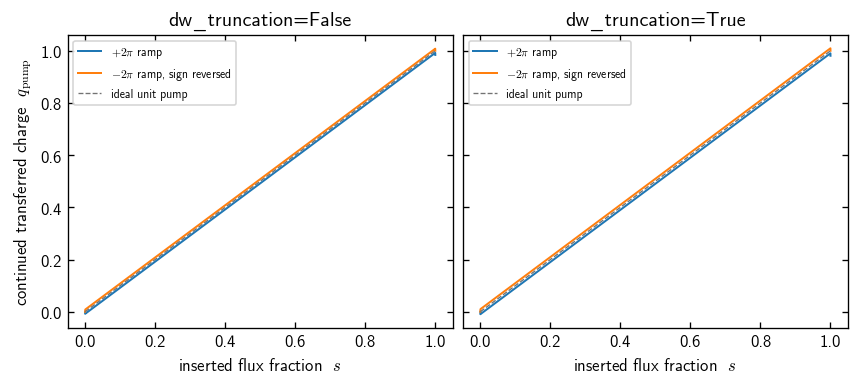

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(7.05, 3.1), sharex=True, sharey=True, constrained_layout=True)
for ax, truncation in zip(axes, DW_TRUNCATIONS):
    for direction, color, label in ((+1, "tab:blue", r"$+2\pi$ ramp"),
                                    (-1, "tab:orange", r"$-2\pi$ ramp, sign reversed")):
        q = PUMP_SERIES[
            (PUMP_SERIES.dw_truncation == truncation)
            & (PUMP_SERIES.direction == direction)
            & (PUMP_SERIES.grid == "endpoint_refined")
        ].sort_values("s")
        sign = 1 if direction == 1 else -1
        ax.plot(q["s"], sign * q["q_pump_continued"], lw=1.2, color=color, label=label)
    ax.plot([0, 1], [0, 1], "--", color="0.45", lw=0.8, label="ideal unit pump")
    ax.set_title(f"dw_truncation={truncation}")
    ax.set_xlabel("inserted flux fraction  $s$")
    ax.legend(fontsize=7)
axes[0].set_ylabel(r"continued transferred charge  $q_{\rm pump}$")
save_figure(fig, "continued_pump_forward_reverse")
plt.show()

## Plot 2 — where the charge goes

Only the forward continued branch is shown. Green is the change in the left wall basin; red is the change in the right wall basin. A unit pump must end at \((-1,+1)\), and the two curves must sum to zero throughout.

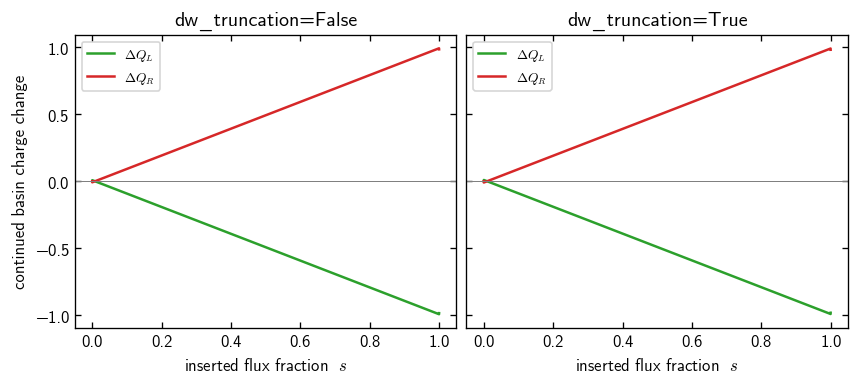

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7.05, 3.1), sharex=True, sharey=True, constrained_layout=True)
for ax, truncation in zip(axes, DW_TRUNCATIONS):
    q = PUMP_SERIES[
        (PUMP_SERIES.dw_truncation == truncation)
        & (PUMP_SERIES.direction == 1)
        & (PUMP_SERIES.grid == "endpoint_refined")
    ].sort_values("s")
    ax.plot(q["s"], q["delta_Q_left_basin_continued"], color="tab:green", label=r"$\Delta Q_L$")
    ax.plot(q["s"], q["delta_Q_right_basin_continued"], color="tab:red", label=r"$\Delta Q_R$")
    ax.axhline(0, color="0.5", lw=0.6)
    ax.set_title(f"dw_truncation={truncation}")
    ax.set_xlabel("inserted flux fraction  $s$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("continued basin charge change")
save_figure(fig, "continued_left_right_charge_balance")
plt.show()

## Plot 3 — mesh convergence and the instantaneous control

Each marker is the endpoint \(q_{\rm pump}(2\pi)\). Filled circles are the continued branch; crosses are the independently re-grounded instantaneous control. Forward values are shown directly and reverse values with their sign reversed. The continued markers should converge to \(1\), while every instantaneous marker should converge to \(0\).

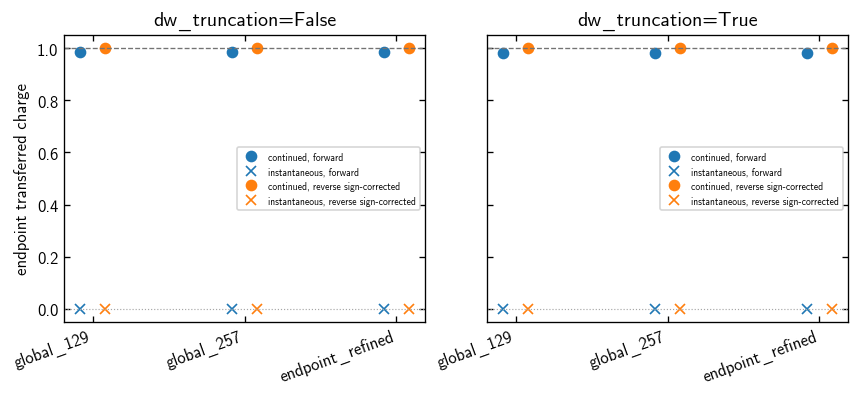

In [8]:
grid_order = [g for g in ("global_129", "global_257", "global_coarse", "global_fine", "endpoint_refined")
              if g in set(PUMP_SUMMARY.grid)]
xpos = np.arange(len(grid_order))
fig, axes = plt.subplots(1, 2, figsize=(7.05, 3.2), sharey=True, constrained_layout=True)
for ax, truncation in zip(axes, DW_TRUNCATIONS):
    for direction, offset, color in ((+1, -0.08, "tab:blue"), (-1, +0.08, "tab:orange")):
        sign = 1 if direction == 1 else -1
        for family, marker, fill in (("continued", "o", color), ("instantaneous", "x", color)):
            q = PUMP_SUMMARY[
                (PUMP_SUMMARY.dw_truncation == truncation)
                & (PUMP_SUMMARY.direction == direction)
                & (PUMP_SUMMARY.state_family == family)
            ].set_index("grid").loc[grid_order]
            ax.plot(xpos + offset, sign * q["q_pump"], marker=marker, ls="none",
                    color=color, markerfacecolor=fill,
                    label=f"{family}, {'forward' if direction == 1 else 'reverse sign-corrected'}")
    ax.axhline(1, color="0.45", lw=0.8, ls="--")
    ax.axhline(0, color="0.65", lw=0.7, ls=":")
    ax.set_xticks(xpos, grid_order, rotation=20, ha="right")
    ax.set_title(f"dw_truncation={truncation}")
    ax.legend(fontsize=5.8)
axes[0].set_ylabel(r"endpoint transferred charge")
save_figure(fig, "pump_mesh_convergence_and_control")
plt.show()

## Plot 4 — final real-space charge profile

This plot answers whether the basin result is genuinely carried by the implemented walls. It shows the final site-column density change after the forward continued cycle. The vertical dotted lines mark \(x=5,15\) in production. A wall pump should produce opposite peaks at those positions and negligible bulk density change.

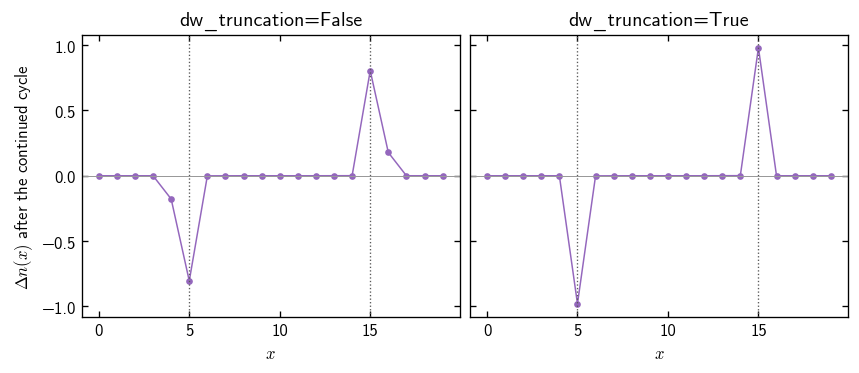

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(7.05, 3.0), sharex=True, sharey=True, constrained_layout=True)
for ax, truncation in zip(axes, DW_TRUNCATIONS):
    q = DENSITY_PROFILE[
        (DENSITY_PROFILE.dw_truncation == truncation)
        & (DENSITY_PROFILE.direction == 1)
        & (DENSITY_PROFILE.grid == "endpoint_refined")
        & (DENSITY_PROFILE.state_family == "continued")
    ]
    ax.plot(q["x"], q["delta_n"], "o-", ms=3, lw=0.9, color="tab:purple")
    for wall in DW_INTERVAL:
        ax.axvline(wall, color="0.35", lw=0.8, ls=":")
    ax.axhline(0, color="0.6", lw=0.6)
    ax.set_title(f"dw_truncation={truncation}")
    ax.set_xlabel(r"$x$")
axes[0].set_ylabel(r"$\Delta n(x)$ after the continued cycle")
save_figure(fig, "final_wall_localized_charge_profile")
plt.show()

## Save compact tables, figures, and a plain-language plot guide

In [10]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    PUMP_SERIES.to_csv(OUTPUT_DIR / "pump_timeseries.csv", index=False)
    PUMP_SUMMARY.to_csv(OUTPUT_DIR / "pump_endpoint_convergence.csv", index=False)
    DENSITY_PROFILE.to_csv(OUTPUT_DIR / "final_density_profiles.csv", index=False)
    manifest = {
        "run_id": RUN_ID, "runtime_seconds": RUNTIME_SECONDS,
        "configuration": CONFIG, "source_sha256": SOURCE_HASH,
        "numerical_validation": [
            {"truncation": k[0], "direction": k[1], **case["validation"]}
            for k, case in RESULTS.items()
        ],
    }
    (OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, default=list))
    guide = """# How to read the refined charge-pump plots

1. continued_pump_forward_reverse: both twist directions are sign-aligned. Agreement with the dashed diagonal means one charge is transferred over one flux quantum.
2. continued_left_right_charge_balance: the left wall must lose exactly what the right wall gains.
3. pump_mesh_convergence_and_control: continued circles should approach 1; instantaneous crosses should approach 0 as the twist mesh is refined.
4. final_wall_localized_charge_profile: the transferred density must form opposite peaks at the two implemented walls, not in the bulk.

This is quasistatic occupied-state continuation of the exact flattened Hamiltonian. It is not a finite-time circuit evolution and does not compute an instantaneous current.
"""
    (OUTPUT_DIR / "PLOT_GUIDE.md").write_text(guide)
    print("Saved:", OUTPUT_DIR)

Saved: /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis/outputs/exact_wall_charge_pump_refined_v1/run_20260901_002219
